##Capstone Project : Vision2Voice
Members : Pallavi Raut, Aniruddh Kulkarni , Keval Shah

Mentor : Prof. Kapil Rathor

In [1]:
#import opendatasets as od

In [2]:
#'od.download("https://www.kaggle.com/datasets/adityajn105/flickr8k")'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#os library for dealing with files
import os
#used to store features extracted by vggnet -16
import pickle
#To deal with string data type
import string
#To create nueral networks
import tensorflow
#Libraries for computation and visualization
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from os import listdir
from pickle import dump
from keras.applications.vgg16 import VGG16
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

In [6]:
os.getcwd()

'/content'

In [7]:
'''
#extract features from each photo in the directory
def extract_features(directory):
	# load the model
	model = VGG16()
	# re-structure the model
	model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
	# summarize
	print(model.summary())
	# extract features from each photo
	features = dict()
	for name in listdir(directory):
		# load an image from file
		filename = directory + '/' + name
		image = load_img(filename, target_size=(224, 224))
		# convert the image pixels to a numpy array
		image = img_to_array(image)
		# reshape data for the model
		image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
		# prepare the image for the VGG model
		image = preprocess_input(image)
		# get features
		feature = model.predict(image, verbose=0)
		# get image id
		image_id = name.split('.')[0]
		# store feature
		features[image_id] = feature
		print('>%s' % name)
	return features

# extract features from all images
directory = "flickr8K/Images"
features = extract_features(directory)
print('Extracted Features: %d' % len(features))
# save to file
dump(features, open('features.pkl', 'wb'))
'''


'\n#extract features from each photo in the directory\ndef extract_features(directory):\n\t# load the model\n\tmodel = VGG16()\n\t# re-structure the model\n\tmodel = Model(inputs=model.inputs, outputs=model.layers[-2].output)\n\t# summarize\n\tprint(model.summary())\n\t# extract features from each photo\n\tfeatures = dict()\n\tfor name in listdir(directory):\n\t\t# load an image from file\n\t\tfilename = directory + \'/\' + name\n\t\timage = load_img(filename, target_size=(224, 224))\n\t\t# convert the image pixels to a numpy array\n\t\timage = img_to_array(image)\n\t\t# reshape data for the model\n\t\timage = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))\n\t\t# prepare the image for the VGG model\n\t\timage = preprocess_input(image)\n\t\t# get features\n\t\tfeature = model.predict(image, verbose=0)\n\t\t# get image id\n\t\timage_id = name.split(\'.\')[0]\n\t\t# store feature\n\t\tfeatures[image_id] = feature\n\t\tprint(\'>%s\' % name)\n\treturn features\n\n# extra

In [8]:
 #load doc into memory
def load_doc(filename):
    # open the file as read only
    file = open(filename, 'r')
    # read all text
    text = file.read()
    # close the file
    file.close()
    return text

filename =  '/content/drive/My Drive/Capstone Data/flickr8k/Flickr8k_text/Flickr8k.token.txt'
# load descriptions
doc = load_doc(filename)

In [9]:
# extract descriptions for images
def load_descriptions(doc):
	mapping = dict()
	# process lines
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		if len(line) < 2:
			continue
		# take the first token as the image id, the rest as the description
		image_id, image_desc = tokens[0], tokens[1:]
		# remove filename from image id
		image_id = image_id.split('.')[0]
		# convert description tokens back to string
		image_desc = ' '.join(image_desc)
		# create the list if needed
		if image_id not in mapping:
			mapping[image_id] = list()
		# store description
		mapping[image_id].append(image_desc)
	return mapping

# parse descriptions
descriptions = load_descriptions(doc)
print('Loaded: %d ' % len(descriptions))

Loaded: 8092 


In [ ]:
descriptions #print all the descriptions

In [ ]:
import string

def clean_descriptions(descriptions):
	# prepare translation table for removing punctuation
	table = str.maketrans('', '', string.punctuation)
	for key, desc_list in descriptions.items():
		for i in range(len(desc_list)):
			desc = desc_list[i]
			# tokenize
			desc = desc.split()
			# convert to lower case
			desc = [word.lower() for word in desc]
			# remove punctuation from each token
			desc = [w.translate(table) for w in desc]
			# remove hanging 's' and 'a'
			desc = [word for word in desc if len(word)>1]
			# remove tokens with numbers in them
			desc = [word for word in desc if word.isalpha()]
			# store as string
			desc_list[i] =  ' '.join(desc)
			print(desc_list[i])
			return desc

# clean descriptions
cleaned = clean_descriptions(descriptions)

In [ ]:
cleaned

['child',
 'in',
 'pink',
 'dress',
 'is',
 'climbing',
 'up',
 'set',
 'of',
 'stairs',
 'in',
 'an',
 'entry',
 'way']

In [ ]:
# convert the loaded descriptions into a vocabulary of words
def to_vocabulary(descriptions):
	# build a list of all description strings
	all_desc = set()
	for key in descriptions.keys():
		[all_desc.update(d.split()) for d in descriptions[key]]
	return all_desc

# summarize vocabulary
vocabulary = to_vocabulary(descriptions)
print('Vocabulary Size: %d' % len(vocabulary))

Vocabulary Size: 9630


In [ ]:
#Set which contains the vocabulary
print(vocabulary)

{'noce', 'domed', 'SUV', 'blocking', 'scores', 'monitor', 'youngsters', 'cuddling', 'draft', 'This', 'five', 'Energizer', 'tray', 'explosions', 'diaper', 'clap', 'point', 'enjoys', 'blue-tinted', 'Behind', 'lilypads', 'Movers', 'Fries', 'dive', 'cart', 'jazz', 'huddle', 'setup', 'sweatsuit', 'probably', 'hairnet', 'doggy', 'plats', 'red-dressed', 'whacking', 'flautist', 'sledders', 'snow-capped', 'tag', 'quaint', 'Amnesty', 'lot', 'will', 'emblazoned', 'locks', 'Athletic', 'paper', 'damaged', 'festival', 'brake', 'crafts', 'receive', 'rock-climbing', 'shrowded', 'site', 'motor-cross', 'beverage', 'sewing', 'whom', 'shadowy', 'boots', 'mascot', 'backing', 'served', 'camcorder', 'goldfish', 'eastern', 'floated', 'urinating', 'skipped', 'clifftop', 'placid', 'competitors', 'grasps', 'kiddy', 'digger', 'dragsters', 'Flaming', 'schools', 'thing', 'dance-floor', 'submerged', 'saxophone', 'records', 'sliding', 'eachothers', 'recoiling', 'nursery', 'skis', 'cob', 'beached', 'fetched', 'mock', 

In [ ]:
# save descriptions to file, one per line
def save_descriptions(descriptions, filename):
	lines = list()
	for key, desc_list in descriptions.items():
		for desc in desc_list:
			lines.append(key + ' ' + desc)
	data = '\n'.join(lines)
	file = open(filename, 'w')
	file.write(data)
	file.close()

# save descriptions
save_descriptions(descriptions, '/content/drive/My Drive/Capstone Data/flickr8k/descriptions.txt')

In [ ]:
# load doc into memory
def load_doc(filename):
	# open the file as read only
	file = open(filename, 'r')
	# read all text
	text = file.read()
	# close the file
	file.close()
	return text

# load a pre-defined list of photo identifiers
def load_set(filename):
	doc = load_doc(filename)
	dataset = list()
	# process line by line
	for line in doc.split('\n'):
		# skip empty lines
		if len(line) < 1:
			continue
		# get the image identifier
		identifier = line.split('.')[0]
		dataset.append(identifier)
	return set(dataset)

In [ ]:
# load clean descriptions into memory
def load_clean_descriptions(filename, dataset):
	# load document
	doc = load_doc(filename)
	descriptions = dict()
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		# split id from description
		image_id, image_desc = tokens[0], tokens[1:]
		# skip images not in the set
		if image_id in dataset:
			# create list
			if image_id not in descriptions:
				descriptions[image_id] = list()
			# wrap description in tokens
			desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
			# store
			descriptions[image_id].append(desc)
	return descriptions

In [ ]:
# load photo features
def load_photo_features(filename, dataset):
	# load all features
	all_features = load(open(filename, 'rb'))
	# filter features
	features = {k: all_features[k] for k in dataset}
	return features

In [ ]:
from pickle import load
# load training dataset (6K)

filename = '/content/drive/My Drive/Capstone Data/flickr8k/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('/content/drive/My Drive/Capstone Data/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# photo features
train_features = load_photo_features('/content/drive/My Drive/Capstone Data/features.pkl', train)
print('Photos: train=%d' % len(train_features))

Dataset: 6000
Descriptions: train=6000
Photos: train=6000


In [ ]:
train_descriptions

{'1000268201_693b08cb0e': ['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
  'startseq A girl going into a wooden building . endseq',
  'startseq A little girl climbing into a wooden playhouse . endseq',
  'startseq A little girl climbing the stairs to her playhouse . endseq',
  'startseq A little girl in a pink dress going into a wooden cabin . endseq'],
 '1001773457_577c3a7d70': ['startseq A black dog and a spotted dog are fighting endseq',
  'startseq A black dog and a tri-colored dog playing with each other on the road . endseq',
  'startseq A black dog and a white dog with brown spots are staring at each other in the street . endseq',
  'startseq Two dogs of different breeds looking at each other on the road . endseq',
  'startseq Two dogs on pavement moving toward each other . endseq'],
 '1002674143_1b742ab4b8': ['startseq A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl . endseq',
  'startseq A little 

In [ ]:
train_features

{'508958120_afe274f726': array([[3.9304705, 0.       , 2.403113 , ..., 0.       , 0.802347 ,
         0.       ]], dtype=float32),
 '426805536_d1d5e68c17': array([[0.       , 2.3219385, 0.       , ..., 0.       , 1.8249576,
         1.1191857]], dtype=float32),
 '3277824093_299cbb3138': array([[3.5968986 , 1.5943404 , 2.5215302 , ..., 0.        , 0.0095506 ,
         0.32205188]], dtype=float32),
 '3681324243_b69fa90842': array([[0.       , 0.       , 2.4630089, ..., 2.1786244, 0.       ,
         0.       ]], dtype=float32),
 '3384528359_e920154177': array([[0.       , 0.6038838, 1.709926 , ..., 2.1251454, 4.1762066,
         0.3780697]], dtype=float32),
 '501520507_c86f805ab8': array([[0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 '3497255828_f27e009aac': array([[0.       , 0.       , 2.5710125, ..., 0.       , 0.       ,
         1.6160235]], dtype=float32),
 '3105929913_94a6882e25': array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         1.3765659]], dtype=fl

In [ ]:
from keras.preprocessing.text import Tokenizer

In [ ]:
# convert a dictionary of clean descriptions to a list of descriptions
def to_lines(descriptions):
	all_desc = list()
	for key in descriptions.keys():
		[all_desc.append(d) for d in descriptions[key]]
	return all_desc

# fit a tokenizer for cleaned caption descriptions
def create_tokenizer(descriptions):
	lines = to_lines(descriptions)
	tokenizer = Tokenizer()
	tokenizer.fit_on_texts(lines)
	return tokenizer

# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)

Vocabulary Size: 7378


In [ ]:
# calculate the length of the description with the most words
def max_length(descriptions):
	lines = to_lines(descriptions)
	return max(len(d.split()) for d in lines)

In [ ]:
descriptions_from_dict_to_list = to_lines(train_descriptions)

In [ ]:
descriptions_from_dict_to_list

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq A girl going into a wooden building . endseq',
 'startseq A little girl climbing into a wooden playhouse . endseq',
 'startseq A little girl climbing the stairs to her playhouse . endseq',
 'startseq A little girl in a pink dress going into a wooden cabin . endseq',
 'startseq A black dog and a spotted dog are fighting endseq',
 'startseq A black dog and a tri-colored dog playing with each other on the road . endseq',
 'startseq A black dog and a white dog with brown spots are staring at each other in the street . endseq',
 'startseq Two dogs of different breeds looking at each other on the road . endseq',
 'startseq Two dogs on pavement moving toward each other . endseq',
 'startseq A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl . endseq',
 'startseq A little girl is sitting in front of a large painted rainbow . endseq',
 'startseq A small girl in

In [ ]:
number_of_captions = len(descriptions_from_dict_to_list)

In [ ]:
print(number_of_captions)

30000


In [ ]:
from numpy import array
from pickle import load
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.utils import to_categorical
from keras.utils import plot_model
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Embedding
from keras.layers import Dropout
from keras.layers import add
from keras.callbacks import ModelCheckpoint

In [ ]:
# create sequences of images, input sequences and output words for an image
def create_sequences(tokenizer, max_length, desc_list, photo, vocab_size):
	X1, X2, y = list(), list(), list()
	# walk through each description for the image
	for desc in desc_list:
		# encode the sequence
		seq = tokenizer.texts_to_sequences([desc])[0]
		# split one sequence into multiple X,y pairs
		for i in range(1, len(seq)):
			# split into input and output pair
			in_seq, out_seq = seq[:i], seq[i]
			# pad input sequence
			in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
			# encode output sequence
			out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
			# store
			X1.append(photo)
			X2.append(in_seq)
			y.append(out_seq)
	return array(X1), array(X2), array(y)

In [ ]:
sample_list =[]
for i in range(0,6):
    sample_list.append(descriptions_from_dict_to_list[i])

In [ ]:
sample_list

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq A girl going into a wooden building . endseq',
 'startseq A little girl climbing into a wooden playhouse . endseq',
 'startseq A little girl climbing the stairs to her playhouse . endseq',
 'startseq A little girl in a pink dress going into a wooden cabin . endseq',
 'startseq A black dog and a spotted dog are fighting endseq']

In [ ]:
photo = train_features['1000268201_693b08cb0e']

In [ ]:
photo

array([[2.507474, 0.      , 0.      , ..., 0.      , 0.      , 0.      ]],
      dtype=float32)

In [ ]:
#Add fully connected network in block diagram
#Cross Validation : Better value for parameters
#Why we are using crossentropy

# define the captioning model
def define_model(vocab_size, max_length):
	# feature extractor model
	inputs1 = Input(shape=(4096,))
	fe1 = Dropout(0.5)(inputs1)
	fe2 = Dense(256, activation='relu')(fe1)
	# sequence model
	inputs2 = Input(shape=(max_length,))
	se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
	se2 = Dropout(0.5)(se1)
	se3 = LSTM(256)(se2)
	# decoder model
	decoder1 = add([fe2, se3])
	decoder2 = Dense(256, activation='relu')(decoder1)
	outputs = Dense(vocab_size, activation='softmax')(decoder2)
	# tie it together [image, seq] [word]
	model = Model(inputs=[inputs1, inputs2], outputs=outputs)
	model.compile(loss='categorical_crossentropy', optimizer='adam',metrics ='accuracy')
	# summarize model
	print(model.summary())
	plot_model(model, to_file='model.png', show_shapes=True)
	return model

In [ ]:
# data generator, intended to be used in a call to model.fit_generator()
def data_generator(descriptions, photos, tokenizer, max_length, vocab_size):
	# loop for ever over images
	while 1:
		for key, desc_list in descriptions.items():
			# retrieve the photo feature
			photo = photos[key][0]
			in_img, in_seq, out_word = create_sequences(tokenizer, max_length, desc_list, photo, vocab_size)
			yield [in_img, in_seq], out_word

In [ ]:
# load training dataset (6K)
filename = '/content/drive/My Drive/Capstone Data/flickr8k/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('/content/drive/My Drive/Capstone Data/flickr8k/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# photo features
train_features = load_photo_features('/content/drive/My Drive/Capstone Data/features.pkl', train)
print('Photos: train=%d' % len(train_features))
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)
# determine the maximum sequence length
max_length = max_length(train_descriptions)
print('Description Length: %d' % max_length)
# prepare sequences
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, train_descriptions, train_features, vocab_size)


Dataset: 6000
Descriptions: train=6000
Photos: train=6000
Vocabulary Size: 7378
Description Length: 40


In [ ]:
# load test set
filename = '/content/drive/My Drive/Capstone Data/flickr8k/Flickr8k_text/Flickr_8k.devImages.txt'
test = load_set(filename)
print('Dataset: %d' % len(test))
# descriptions
test_descriptions = load_clean_descriptions('/content/drive/My Drive/Capstone Data/flickr8k/descriptions.txt', test)
print('Descriptions: test=%d' % len(test_descriptions))
# photo features
test_features = load_photo_features('/content/drive/My Drive/Capstone Data/features.pkl', test)
print('Photos: test=%d' % len(test_features))
# prepare sequences
X1test, X2test, ytest = create_sequences(tokenizer, max_length, test_descriptions, test_features, vocab_size)

Dataset: 1000
Descriptions: test=1000
Photos: test=1000


In [ ]:
generator = data_generator(train_descriptions, train_features, tokenizer, max_length, vocab_size)

In [ ]:

# define the model
model = define_model(vocab_size, max_length)
# define checkpoint callback
filepath = 'model-ep{epoch:03d}-loss{loss:.3f}-val_loss{val_loss:.3f}.h5'
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 40)]                 0         []                            
                                                                                                  
 input_1 (InputLayer)        [(None, 4096)]               0         []                            
                                                                                                  
 embedding (Embedding)       (None, 40, 256)              1888768   ['input_2[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 4096)                 0         ['input_1[0][0]']             
                                                                                              

In [ ]:
'''
# train the model, run epochs manually and save after each epoch
epochs = 10
steps = len(train_descriptions)

for i in range(epochs):
   # create the data generator
   generator = data_generator(train_descriptions, train_features, tokenizer, max_length, vocab_size)
   # fit for one epoch
   model.fit_generator(generator, epochs=1, steps_per_epoch=steps, verbose=1)
   #save model
   model.save('/content/drive/My Drive/Capstone Data/Saved_Models/model_' + str(i) + '.h5')

#model fitting should be outside the for loop ,what accuracy is given?
'''

<ipython-input-42-9434a1139727>:9: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(generator, epochs=1, steps_per_epoch=steps, verbose=1)


  39/3000 [..............................] - ETA: 19:12 - loss: 4.0197 - accuracy: 0.2620

KeyboardInterrupt: ignored

In [ ]:
# map an integer to a word
def word_for_id(integer, tokenizer):
	for word, index in tokenizer.word_index.items():
		if index == integer:
			return word
	return None
import numpy as np
# generate a description for an image
def generate_desc(model, tokenizer, photo, max_length):
	# seed the generation process
	in_text = 'startseq'
	# iterate over the whole length of the sequence
	for i in range(max_length):
		# integer encode input sequence
		sequence = tokenizer.texts_to_sequences([in_text])[0]
		# pad input
		sequence = pad_sequences([sequence], maxlen=max_length)
		# predict next word
		yhat = model.predict([photo,sequence], verbose=0)
		# convert probability to integer
		yhat = np.argmax(yhat)
		# map integer to word
		word = word_for_id(yhat, tokenizer)
		# stop if we cannot map the word
		if word is None:
			break
		# append as input for generating the next word
		in_text += ' ' + word
		# stop if we predict the end of the sequence
		if word == 'endseq':
			break
	return in_text


In [ ]:
from nltk.translate import bleu
from nltk.translate.bleu_score import corpus_bleu


In [ ]:
# evaluate the skill of the model
def evaluate_model(model, descriptions, photos, tokenizer, max_length):
	actual, predicted = list(), list()
	# step over the whole set
	for key, desc_list in descriptions.items():
		# generate description
		yhat = generate_desc(model, tokenizer, photos[key], max_length)
		# store actual and predicted
		references = [d.split() for d in desc_list]
		actual.append(references)
		predicted.append(yhat.split())
    # calculate BLEU score
	print('BLEU-1: %f' % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
	print('BLEU-2: %f' % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
	print('BLEU-3: %f' % corpus_bleu(actual, predicted, weights=(0.3, 0.3, 0.3, 0)))
	print('BLEU-4: %f' % corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)))


In [ ]:
# prepare tokenizer on train set

# load training dataset (6K)
filename = '/content/drive/My Drive/Capstone Data/flickr8k/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('/content/drive/My Drive/Capstone Data/flickr8k/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)
# determine the maximum sequence length
max_length = max_length(train_descriptions)
print('Description Length: %d' % max_length)


Dataset: 6000
Descriptions: train=6000
Vocabulary Size: 7378


TypeError: ignored

In [ ]:
from keras.models import load_model

In [ ]:
'''
# prepare test set

# load test set
filename = '/content/drive/My Drive/Capstone Data/flickr8k/Flickr8k_text/Flickr_8k.testImages.txt'
test = load_set(filename)
print('Dataset: %d' % len(test))
# descriptions
test_descriptions = load_clean_descriptions('descriptions.txt', test)
print('Descriptions: test=%d' % len(test_descriptions))
# photo features
test_features = load_photo_features('features.pkl', test)
print('Photos: test=%d' % len(test_features))

# load the model
filename = 'flickr8k/model_0.h5'
model = load_model(filename)
# evaluate model
evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)
'''


In [ ]:
from tensorflow.keras.preprocessing.image import load_img
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import img_to_array
from keras.models import load_model
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

In [ ]:
# fit a tokenizer given caption descriptions
def create_tokenizer(descriptions):
	lines = to_lines(descriptions)
	tokenizer = Tokenizer()
	tokenizer.fit_on_texts(lines)
	return tokenizer

# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)

In [ ]:
def extract_features(filename):
    # load the model
    model = VGG16()
    # re-structure the model
    model.layers.pop()
    model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
    # load the photo
    image = load_img(filename, target_size=(224, 224))
    # convert the image pixels to a numpy array
    image = img_to_array(image)
    # reshape data for the model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # prepare the image for the VGG model
    image = preprocess_input(image)
    # get features
    feature = model.predict(image, verbose=0)
    return feature

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

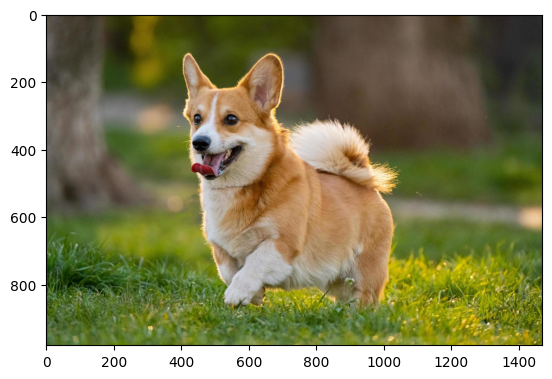

In [ ]:
#Image downloaded from internet and given to the model to generate a caption
img_to_test = "/content/drive/My Drive/Capstone Data/flickr8k/dog.jpg"
img = cv2.imread(img_to_test)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
# pre-define the max sequence length (from training)
max_length = 40
tokenizer = create_tokenizer(train_descriptions)
# load the model
model = load_model('/content/drive/My Drive/Capstone Data/Saved_Models/model_49.h5')
# load and prepare the photograph
photo = extract_features(img_to_test)


In [ ]:
#generate description
description = generate_desc(model, tokenizer, photo, max_length)
description = ' '.join(description.split()[1:-1])

man in a red shirt is standing on a



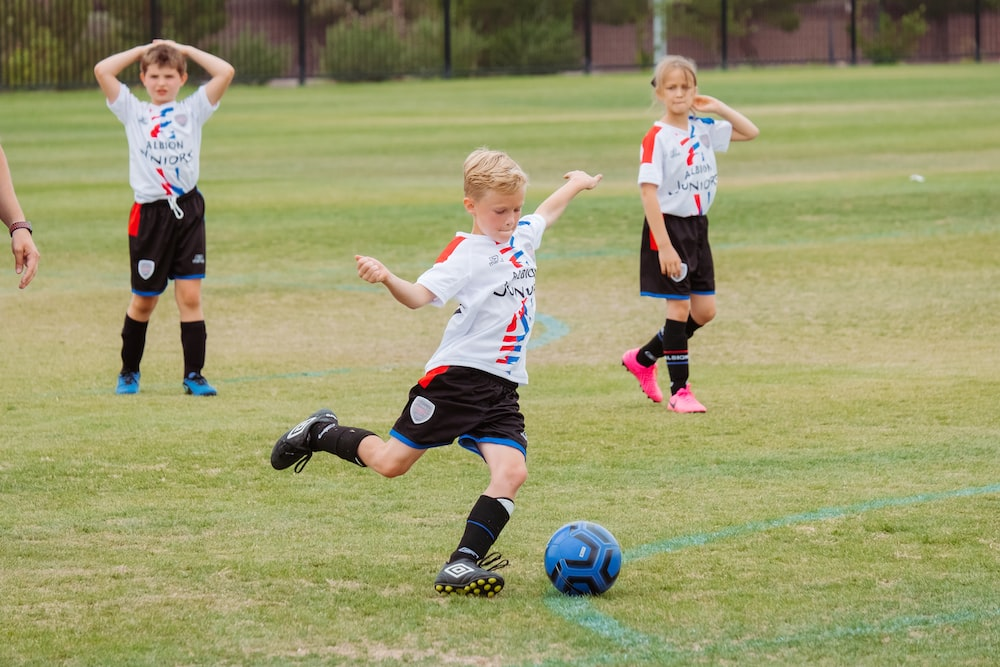

In [ ]:
print(description)
print()
cv2_imshow(img)

###Object Detection

In [ ]:
!pip install ultralytics

In [ ]:
!pip install cvzone

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cvzone
import math
import time
import os
from PIL import Image
import shutil
from google.colab.patches import cv2_imshow


0: 448x640 1 dog, 2829.5ms
Speed: 7.8ms preprocess, 2829.5ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


Cropped and saved dog_0.97.jpg
Cropping completed.


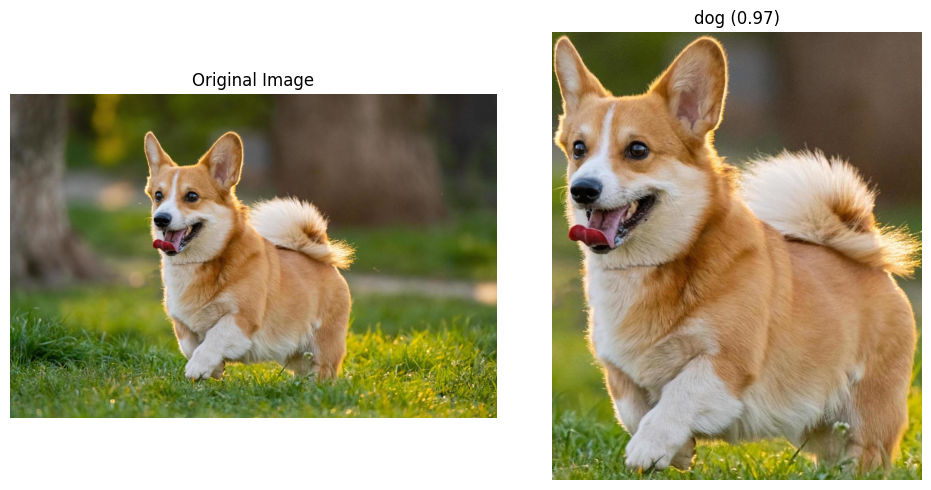

In [ ]:
def detect_and_crop_objects(image_path, output_folder):
    # Clear the output folder to remove previous cropped images
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder, exist_ok=True)

    # Load the image
    image = cv2.imread(image_path)

    # Load the YOLO model (replace "yolov8x.pt" with your model's path)
    model = YOLO("yolov8x.pt")

    # Perform object detection
    results = model.predict(image)
    result = results[0]

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, len(result.boxes) + 1, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    for i, box in enumerate(result.boxes):
        class_id = result.names[box.cls[0].item()]
        cords = box.xyxy[0].tolist()
        cords = [round(x) for x in cords]
        conf = round(box.conf[0].item(), 2)

        # Load the original image
        image = Image.open(image_path)

        # Extract coordinates
        x_min, y_min, x_max, y_max = cords

        # Crop the image using the coordinates
        cropped_image = image.crop((x_min, y_min, x_max, y_max))

        # Generate a filename for the cropped image
        filename = f"{class_id}_{conf}.jpg"

        # Save the cropped image to the output folder
        cropped_image.save(os.path.join(output_folder, filename))

        # Display the cropped image
        plt.subplot(1, len(result.boxes) + 1, i + 2)
        plt.imshow(cropped_image)
        plt.title(f"{class_id} ({conf})")
        plt.axis('off')

        print(f"Cropped and saved {filename}")

    print("Cropping completed.")

    # Show the original and cropped images
    plt.tight_layout()
    plt.show()

# Example usage:
input_image_path = "/content/drive/My Drive/Capstone Data/flickr8k/dog.jpg"
#Put path of google drive
output_folder = "cropped_images"
detect_and_crop_objects(input_image_path, output_folder)


In [ ]:
obj =cv2.imread('/content/cropped_images/dog_0.97.jpg')

In [ ]:
# pre-define the max sequence length (from training)
max_length = 40
tokenizer = create_tokenizer(train_descriptions)
# load the model
model = load_model('/content/drive/My Drive/Capstone Data/Saved_Models/model_49.h5')
# load and prepare the photograph
photo = extract_features('/content/cropped_images/dog_0.97.jpg')

In [ ]:
#generate description
description2 = generate_desc(model, tokenizer, photo, max_length)
description2 = ' '.join(description2.split()[1:-1])

a black dog is running through a field



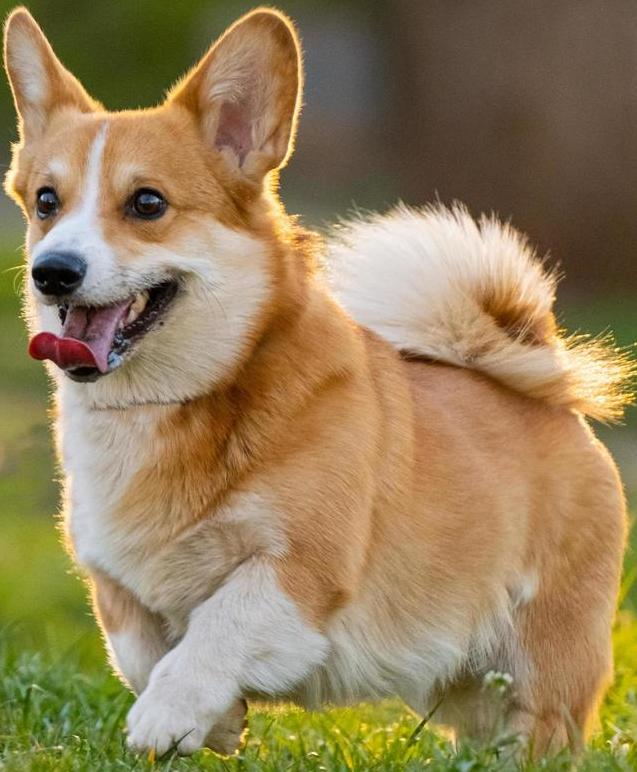

In [ ]:
print(description2)
print()
cv2_imshow(obj)